# Iris Classification Lab - MLflow Experiment Tracking
This lab demonstrates MLflow experiment tracking using the Iris dataset instead of wine quality data.

In [31]:
import mlflow
import mlflow.pyfunc
import mlflow.sklearn
import numpy as np
import pandas as pd
import sklearn
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from mlflow.models.signature import infer_signature
import cloudpickle
import time

## Step 1: Data Exploration
Visualizing the distribution of Iris classes.

In [32]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="quality")
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


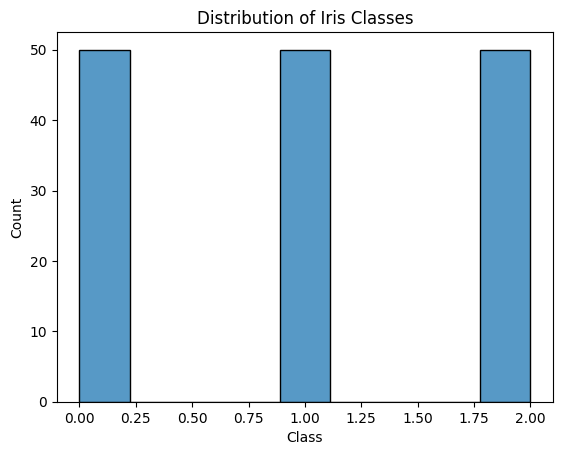

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize distribution of target classes
sns.histplot(y, kde=False)
plt.title("Distribution of Iris Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Step 2: Exploratory Data Analysis (EDA)
Box plots to identify key features for classification.

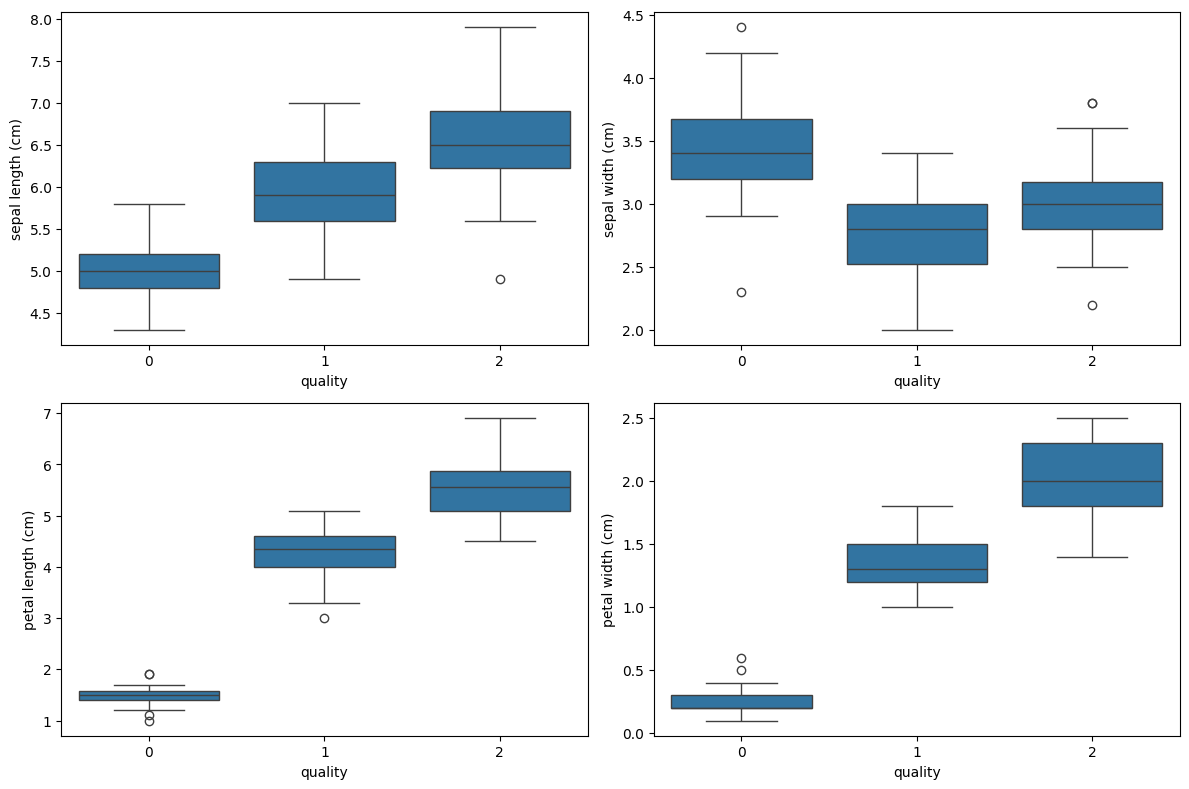

In [34]:
dims = (2, 2)
f, axes = plt.subplots(dims[0], dims[1], figsize=(12, 8))
axis_i, axis_j = 0, 0

for col in X.columns:
    sns.boxplot(x=y, y=X[col], ax=axes[axis_i, axis_j])
    axis_j += 1
    if axis_j == dims[1]:
        axis_i += 1
        axis_j = 0
plt.tight_layout()
plt.show()

Petal length and petal width appear to be the strongest predictors of Iris species.

## Step 3: Check Missing Data

In [35]:
X.isna().any()

sepal length (cm)    False
sepal width (cm)     False
petal length (cm)    False
petal width (cm)     False
dtype: bool

## Step 4: Data Splitting

In [36]:
X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=0.6, random_state=123)
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=123)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (90, 4), Val: (30, 4), Test: (30, 4)


## Step 5: Build Baseline Model with MLflow Tracking

In [37]:
with mlflow.start_run(run_name='iris_random_forest'):
    n_estimators = 10
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    model.fit(X_train, y_train)
    
    predictions_test = model.predict(X_test)
    acc = accuracy_score(y_test, predictions_test)
    
    mlflow.log_param('n_estimators', n_estimators)
    mlflow.log_metric('accuracy', acc)
    
    signature = infer_signature(X_train, model.predict(X_train))
    mlflow.sklearn.log_model(model, "iris_rf_model", signature=signature)
    
    print(f"Accuracy: {acc:.4f}")
    run_id = mlflow.active_run().info.run_id
    print(f"Run ID: {run_id}")

2026/03/13 21:20:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 21:20:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.9000
Run ID: a587b2db8e914757be3b37d2c5c7b681


## Step 6: Feature Importance Analysis

In [38]:
feature_importances = pd.DataFrame(
    model.feature_importances_,
    index=X_train.columns.tolist(),
    columns=['importance']
)
feature_importances.sort_values('importance', ascending=False)

,importance
petal width (cm),0.490352
petal length (cm),0.331832
sepal length (cm),0.151717
sepal width (cm),0.026099


## Step 7: Model Registration

In [39]:
model_name = "iris_quality"
model_version = mlflow.register_model(f"runs:/{run_id}/iris_rf_model", model_name)
time.sleep(10)
print(f"Model registered: version {model_version.version}")

Registered model 'iris_quality' already exists. Creating a new version of this model...
2026/03/13 21:20:20 WARNING mlflow.tracking._model_registry.fluent: Run with id a587b2db8e914757be3b37d2c5c7b681 has no artifacts at artifact path 'iris_rf_model', registering model based on models:/m-80932275da234edf8caf3869818b3758 instead
Created version '4' of model 'iris_quality'.


Model registered: version 4


In [40]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
client.transition_model_version_stage(
    name=model_name,
    version=model_version.version,
    stage="Production",
)
print(f"Model transitioned to Production!")

Model transitioned to Production!


C:\Users\sweth\AppData\Local\Temp\ipykernel_34792\412280066.py:4: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


## Step 8: Load Production Model & Inference

In [41]:
loaded_model = mlflow.pyfunc.load_model(f"models:/{model_name}/production")
preds = loaded_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")

Accuracy: 0.9000


## Conclusion
This lab demonstrated MLflow experiment tracking using the Iris dataset. 
We trained a Random Forest classifier, logged metrics and parameters, 
registered the model, transitioned it to production, and performed inference.